## Setup

In [93]:
from pathlib import Path
from tempfile import mkdtemp
from shutil import rmtree
import sys

sys.path.append('..')
from utils import draw_pr_curve_from_cv_results

In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [95]:

from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from aeon.regression.distance_based import KNeighborsTimeSeriesRegressor
from sklearn.model_selection import GridSearchCV, cross_validate, cross_val_predict
from aeon.transformations.collection import Normalizer
from sklearn.pipeline import Pipeline
from aeon.distances import dtw_distance

In [96]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [97]:
cachedir = mkdtemp()

In [98]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)

Define dtw distances with different constraints for hyperparameter tuning.

In [99]:
def dtw005(x, y):
    return dtw_distance(x, y, window=.05)

def dtw01(x, y):
    return dtw_distance(x, y, window=.1)

In [100]:
def plot_results(cv_results):
    results = pd.DataFrame(cv_results)
    results['param_clf__distance'] = results['param_clf__distance'].map(
    lambda x: f'dtw (window=0.{str(x).split()[1][4:]})' if str(x).startswith('<') else x
        )
    sns.relplot(results, x='param_clf__n_neighbors', y='mean_test_score',
            hue='param_clf__distance', style='param_clf__weights',
            kind='line')

def print_cv_results(cv_results):
    for key, value in cv_results.items():
        if key.startswith('test'):
            print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

## Shape based classification and regression with KNN

### Action

In [9]:
train_y = train['action']
train_y.shape

(850,)

In [10]:
pipeline = Pipeline([
    ('scaler', Normalizer()),
    ('clf', KNeighborsTimeSeriesClassifier())],
    memory=cachedir
)

In [11]:
ks = np.arange(1, 60, 4)

param_grid = {'clf__distance': ('euclidean', dtw005, dtw01),
    'clf__n_neighbors': ks,
    'clf__weights': ('uniform', 'distance')
    }

`TSCGridSearchCV` already uses stratified kfold cross-validation if the target is binary or multiclass. It is also impossible to use `InstanceSplitter` properly.

In [12]:
grid = GridSearchCV(
    pipeline, param_grid=param_grid,
    scoring='f1', n_jobs=-1, verbose=2,
)

In [13]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.7s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.7s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.7s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.8s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.7s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.7s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.7s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.9s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; to

GridSearchCV(estimator=Pipeline(memory='/tmp/tmpl74oqfkl',
                                steps=[('scaler', Normalizer()),
                                       ('clf',
                                        KNeighborsTimeSeriesClassifier())]),
             n_jobs=-1,
             param_grid={'clf__distance': ('euclidean',
                                           <function dtw005 at 0x7f9b293607c0>,
                                           <function dtw01 at 0x7f9b29360860>),
                         'clf__n_neighbors': array([ 1,  5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57]),
                         'clf__weights': ('uniform', 'distance')},
             scoring='f1', verbose=2)

In [14]:
print(grid.best_score_)
print(grid.best_params_)

0.5740621234039704
{'clf__distance': <function dtw01 at 0x7f9b29360860>, 'clf__n_neighbors': np.int64(33), 'clf__weights': 'uniform'}


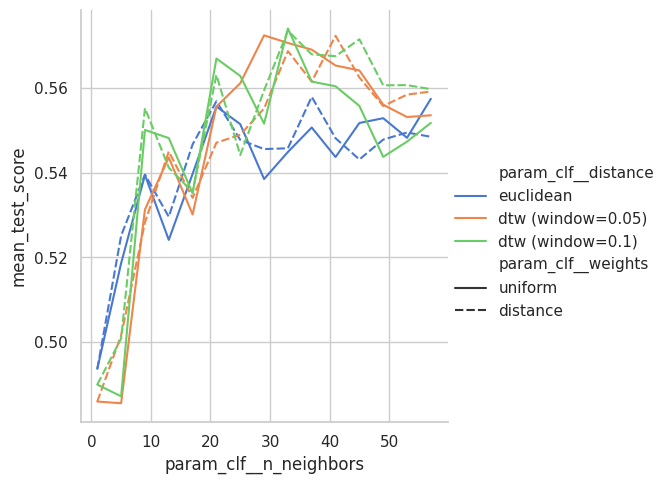

In [15]:
plot_results(grid.cv_results_)

Generally speaking, performance is better when using Dynamic Time Warping as distance function. Impact of the Sakoe Chiba band window isn't very noticeable.
Performance of the model plateaus around 30 neighbors.

In [16]:
cv_results = cross_validate(grid.best_estimator_, train_X, train_y, n_jobs=-1,
                            scoring=('f1', 'precision', 'recall', 'average_precision'),
                            return_estimator=True, return_indices=True)

In [17]:
print_cv_results(cv_results)

f1: 0.57 (0.04)
precision: 0.59 (0.05)
recall: 0.56 (0.05)
average_precision: 0.59 (0.04)


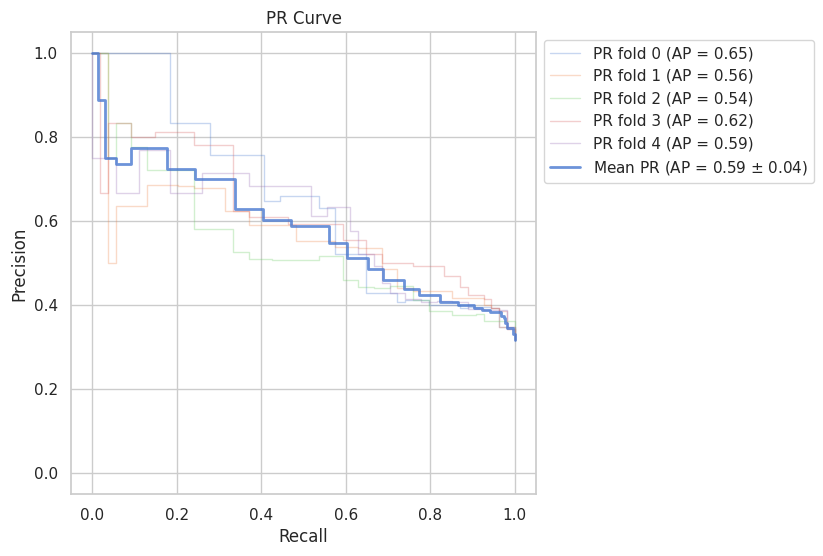

In [18]:
draw_pr_curve_from_cv_results(cv_results, train_X, train_y)

In [19]:
action_knn = grid.best_estimator_

### Rating Category

In [20]:
train_y = train['rating_category']

In [21]:
# Use macro f1 for multiclass classification
grid.scoring = 'f1_macro'

In [22]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.2s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.2s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.2s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; to

GridSearchCV(estimator=Pipeline(memory='/tmp/tmpl74oqfkl',
                                steps=[('scaler', Normalizer()),
                                       ('clf',
                                        KNeighborsTimeSeriesClassifier())]),
             n_jobs=-1,
             param_grid={'clf__distance': ('euclidean',
                                           <function dtw005 at 0x7f9b293607c0>,
                                           <function dtw01 at 0x7f9b29360860>),
                         'clf__n_neighbors': array([ 1,  5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57]),
                         'clf__weights': ('uniform', 'distance')},
             scoring='f1_macro', verbose=2)

In [23]:
print(grid.best_score_)
print(grid.best_params_)

0.2679143016714525
{'clf__distance': <function dtw01 at 0x7f9b29360860>, 'clf__n_neighbors': np.int64(9), 'clf__weights': 'distance'}


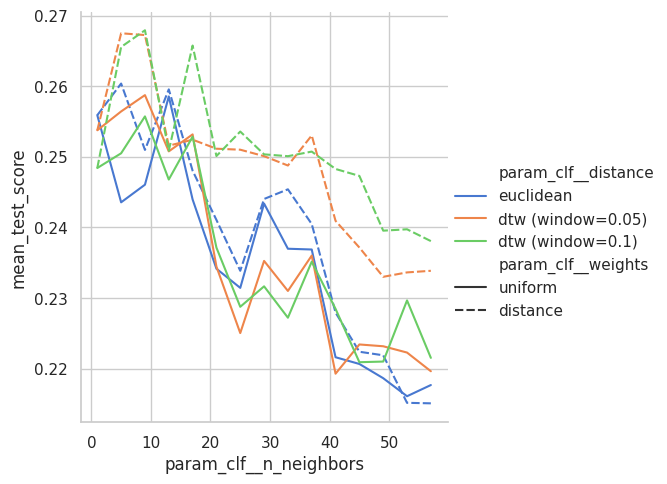

In [24]:
plot_results(grid.cv_results_)

In [25]:
cv_results = cross_validate(grid.best_estimator_, train_X, train_y, n_jobs=-1,
                            scoring=('f1_macro', 'accuracy', 'precision_macro', 'recall_macro'))

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter t

In [26]:
print_cv_results(cv_results)

f1_macro: 0.27 (0.02)
accuracy: 0.42 (0.02)
precision_macro: 0.30 (0.03)
recall_macro: 0.27 (0.02)


In [27]:
rating_knn = grid.best_estimator_

### Rating (regression)

In [29]:
pipeline = Pipeline([
    ('scaler', Normalizer()),
    ('regressor', KNeighborsTimeSeriesRegressor())
])

In [35]:
regressor_param_grid = {
    key.replace('clf', 'regressor'): value
    for key, value
    in param_grid.items()
}

In [39]:
train_y = train['rating']
grid = GridSearchCV(
    pipeline, param_grid=regressor_param_grid,
    scoring='neg_mean_squared_error', n_jobs=-1, verbose=2,
)

In [40]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.6s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.6s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.7s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.6s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.7s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.7s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.7s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.7s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=distance

GridSearchCV(estimator=Pipeline(steps=[('scaler', Normalizer()),
                                       ('regressor',
                                        KNeighborsTimeSeriesRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__distance': ('euclidean',
                                                 <function dtw005 at 0x7f9b293607c0>,
                                                 <function dtw01 at 0x7f9b29360860>),
                         'regressor__n_neighbors': array([ 1,  5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57]),
                         'regressor__weights': ('uniform', 'distance')},
             scoring='neg_mean_squared_error', verbose=2)

In [41]:
print(grid.best_score_)
print(grid.best_params_)

-0.6409871351018765
{'regressor__distance': <function dtw005 at 0x7f9b293607c0>, 'regressor__n_neighbors': np.int64(29), 'regressor__weights': 'distance'}


In [42]:
train['rating'].var()

np.float64(0.8154520889627935)

Sum of square error is in fact smaller that the sample variance of the target variable, so the regressor is doing better than predicting the mean.

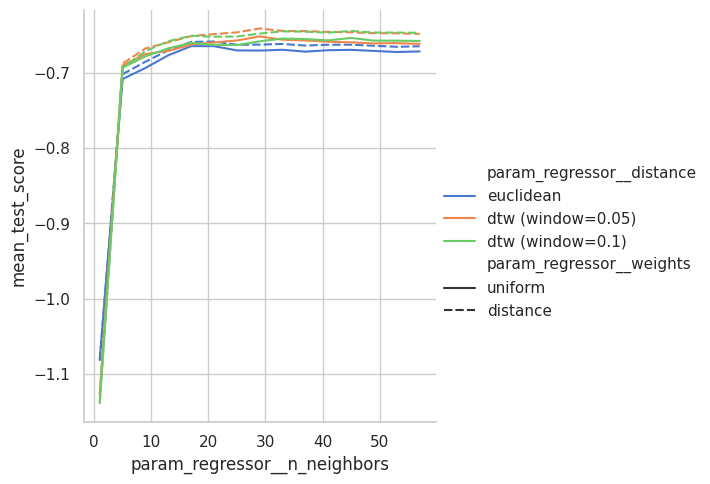

In [49]:
results = pd.DataFrame(grid.cv_results_)

results['param_regressor__distance'] = results['param_regressor__distance'].map(
lambda x: f'dtw (window=0.{str(x).split()[1][4:]})' if str(x).startswith('<') else x
    )
sns.relplot(results, x='param_regressor__n_neighbors', y='mean_test_score',
        hue='param_regressor__distance', style='param_regressor__weights',
        kind='line')

In [ ]:
cv_results = cross_validate(grid.best_estimator_, train_X, train_y, n_jobs=-1,
                            scoring=('neg_mean_squared_error', 'r2'))

In [55]:
print_cv_results(cv_results)

neg_mean_squared_error: -0.64 (0.11)
r2: 0.20 (0.06)


In [54]:
regressor_knn = grid.best_estimator_

In [57]:
y_pred = cross_val_predict(regressor_knn, train_X, train_y, n_jobs=-1)

In [63]:
corr = pearsonr(y_pred, train_y)
corr

PearsonRResult(statistic=np.float64(0.46244399731920244), pvalue=np.float64(2.910392881323489e-46))

Text(4, 8.5, 'Pearson R:0.46 (p value: 0.00)')

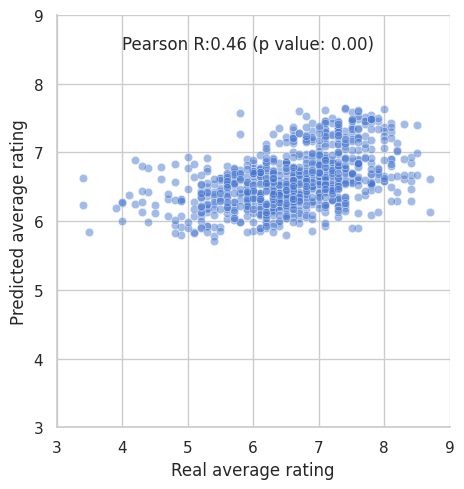

In [69]:
sns.relplot(x=train_y, y=y_pred, alpha=.5)
plt.xlim((3, 9))
plt.ylim((3, 9))
plt.xlabel("Real average rating")
plt.ylabel("Predicted average rating")
plt.text(4, 8.5,
         f"Pearson R:{corr.correlation:.2f} (p value: {corr.pvalue:.2f})")


## Structure based classification and regression with knn

In [74]:
import pycatch22
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [83]:
result = pycatch22.catch22_all(train_X[0][0], catch24=True, short_names=True)
columns = result['short_names']

In [88]:
%%time
data = []
for ts in train_X:
    values = pycatch22.catch22_all(ts[0], catch24=True)['values']
    data.append(values)
train_c22 = pd.DataFrame(data, columns=columns)
train_c22.index = train.index

CPU times: user 300 ms, sys: 6.63 ms, total: 306 ms
Wall time: 318 ms


In [89]:
train_c22.head()

,mode_5,mode_10,acf_timescale,acf_first_min,ami2,trev,high_fluctuation,stretch_high,transition_matrix,periodicity,...,outlier_timing_neg,centroid_freq,stretch_decreasing,entropy_pairs,rs_range,dfa,low_freq_power,forecast_error,mean,SD
id,,,,,,,,,,,,,,,,,,,,,
tt10855768,-0.333098,-0.569656,3.292878,9,0.231946,-0.049935,0.767677,8.0,0.062500,13,...,0.550,0.817875,12.0,1.717638,0.314286,0.314286,0.392699,0.585646,640039.02,7.741079e+05
tt3766354,-0.204680,-0.447203,5.038619,10,0.384456,-0.035084,0.676768,20.0,0.074074,13,...,0.480,0.855605,10.0,1.544890,0.171429,0.600000,0.147262,0.370692,1975049.87,2.740085e+06
tt6791096,-0.235415,-0.476199,4.240450,9,0.381551,-0.037754,0.535354,20.0,0.074074,13,...,0.475,0.845503,12.0,1.499035,0.171429,0.600000,0.196350,0.443455,947198.80,1.281488e+06
tt1821549,-0.968873,-0.759462,3.452775,8,0.382275,0.029799,0.787879,18.0,0.002604,14,...,-0.550,0.877449,7.0,1.670886,0.828571,0.742857,0.392699,0.713396,131952.38,8.647096e+04
tt7144666,-0.305268,-0.580867,5.878877,9,0.412512,-0.022879,0.676768,25.0,0.074074,14,...,0.555,0.843426,6.0,1.452820,0.171429,0.600000,0.098175,0.338991,1710723.00,1.832369e+06


In [90]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

### Action

In [91]:
param_grid = {'clf__metric': ('euclidean', 'manhattan'),
    'clf__n_neighbors': ks,
    'clf__weights': ('uniform', 'distance')
    }

In [92]:
train_y = train['action']

In [93]:
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)

In [96]:
%%time
grid.fit(train_c22, train_y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=un

GridSearchCV(error_score='raise',
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'clf__metric': ('euclidean', 'manhattan'),
                         'clf__n_neighbors': array([ 1,  5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57]),
                         'clf__weights': ('uniform', 'distance')},
             scoring='f1', verbose=2)

In [97]:
print(grid.best_score_)
print(grid.best_params_)

0.5624916312555197
{'clf__metric': 'manhattan', 'clf__n_neighbors': np.int64(17), 'clf__weights': 'distance'}


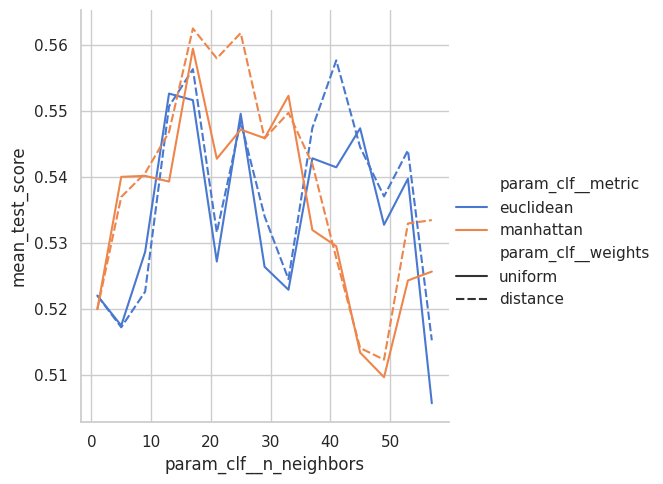

In [98]:
results = pd.DataFrame(grid.cv_results_)
results.fillna(0, inplace=True)
sns.relplot(results, x='param_clf__n_neighbors', y='mean_test_score',
            hue='param_clf__metric',
            style='param_clf__weights',
            kind='line')

In [99]:
action_feat_knn = grid.best_estimator_

In [100]:
cv_results = cross_validate(grid.best_estimator_, train_c22, train_y, n_jobs=-1,
                            scoring=('f1', 'precision', 'recall', 'average_precision'),
                            return_estimator=True, return_indices=True)

In [101]:
print_cv_results(cv_results)

f1: 0.56 (0.03)
precision: 0.62 (0.03)
recall: 0.52 (0.05)
average_precision: 0.64 (0.02)


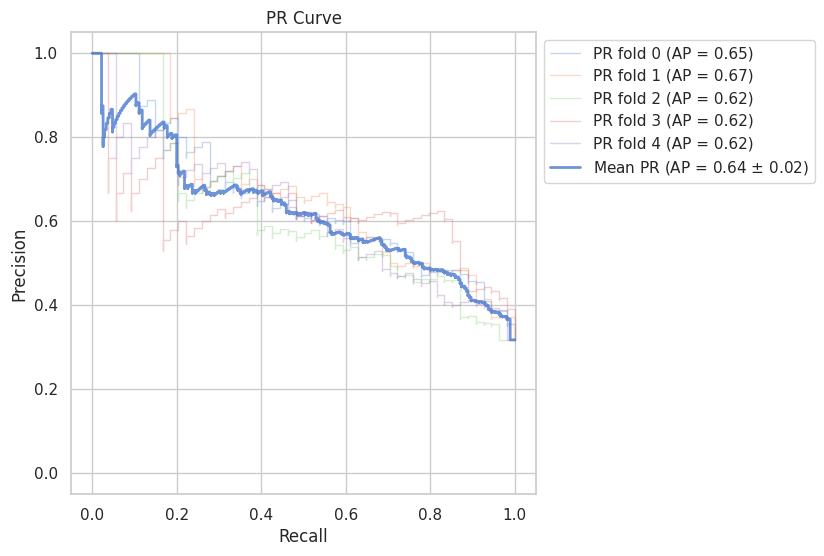

In [102]:
draw_pr_curve_from_cv_results(cv_results, train_c22, train_y)

### Rating Category

In [103]:
train_y = train['rating_category']
grid.scoring = 'f1_macro'

In [104]:
%%time
grid.fit(train_c22, train_y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV

GridSearchCV(error_score='raise',
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'clf__metric': ('euclidean', 'manhattan'),
                         'clf__n_neighbors': array([ 1,  5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57]),
                         'clf__weights': ('uniform', 'distance')},
             scoring='f1_macro', verbose=2)

In [105]:
print(grid.best_score_)
print(grid.best_params_)

0.29154171154218067
{'clf__metric': 'manhattan', 'clf__n_neighbors': np.int64(13), 'clf__weights': 'distance'}


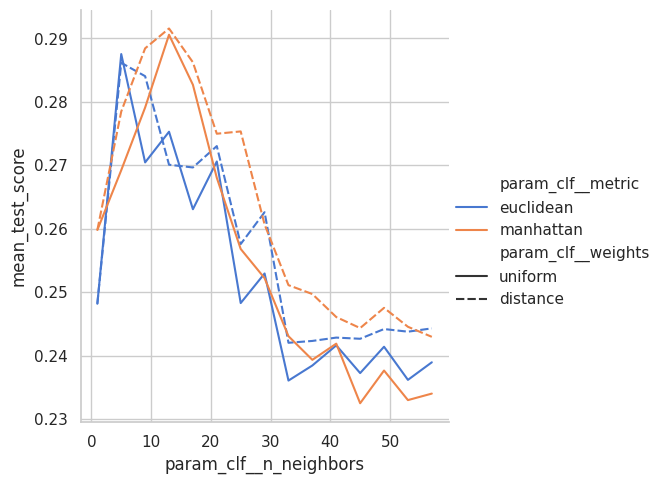

In [106]:
results = pd.DataFrame(grid.cv_results_)
results.fillna(0, inplace=True)
sns.relplot(results, x='param_clf__n_neighbors', y='mean_test_score',
            hue='param_clf__metric',
            style='param_clf__weights',
            kind='line')

In [107]:
rating_feat_knn = grid.best_estimator_

In [109]:
cv_results = cross_validate(grid.best_estimator_, train_c22, train_y, n_jobs=-1,
                            scoring=('f1_macro', 'accuracy', 'precision_macro', 'recall_macro'))

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter t

In [110]:
print_cv_results(cv_results)

f1_macro: 0.29 (0.03)
accuracy: 0.44 (0.03)
precision_macro: 0.33 (0.05)
recall_macro: 0.30 (0.02)


### Rating (regression)

In [101]:
train_y = train['rating']

In [102]:
param_grid = {'regressor__metric': ('euclidean', 'manhattan'),
    'regressor__n_neighbors': ks,
    'regressor__weights': ('uniform', 'distance')
    }

In [103]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])

grid = GridSearchCV(
    pipeline, param_grid=param_grid, n_jobs=-1, verbose=2,
    scoring='neg_mean_squared_error'
)

In [104]:
%%time
grid.fit(train_c22, train_y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=5, regressor__weights=uniform; total time=   0.0s
[CV] END regressor__metric=euclidean, regress

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__metric': ('euclidean', 'manhattan'),
                         'regressor__n_neighbors': array([ 1,  5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57]),
                         'regressor__weights': ('uniform', 'distance')},
             scoring='neg_mean_squared_error', verbose=2)

In [105]:
print(grid.best_score_)
print(grid.best_params_)

-0.5983278606619804
{'regressor__metric': 'manhattan', 'regressor__n_neighbors': np.int64(25), 'regressor__weights': 'distance'}


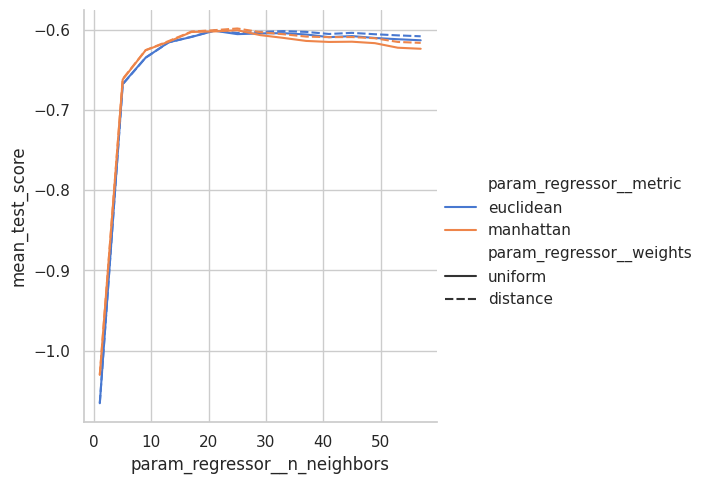

In [106]:
results = pd.DataFrame(grid.cv_results_)
results.fillna(0, inplace=True)
sns.relplot(results, x='param_regressor__n_neighbors', y='mean_test_score',
            style='param_regressor__weights', hue='param_regressor__metric',
            kind='line')

In [107]:
regressor_feat_knn = grid.best_estimator_

In [108]:
cv_results = cross_validate(grid.best_estimator_, train_c22, train_y, n_jobs=-1,
                            scoring=('neg_mean_squared_error', 'r2'))
print_cv_results(cv_results)

neg_mean_squared_error: -0.60 (0.09)
r2: 0.25 (0.09)


In [109]:
y_pred = cross_val_predict(regressor_feat_knn, train_c22, train_y, n_jobs=-1)
corr = pearsonr(y_pred, train_y)
corr

PearsonRResult(statistic=np.float64(0.5173313759265931), pvalue=np.float64(2.332217485529398e-59))

Text(4, 8.5, 'Pearson R:0.52 (p value: 0.00)')

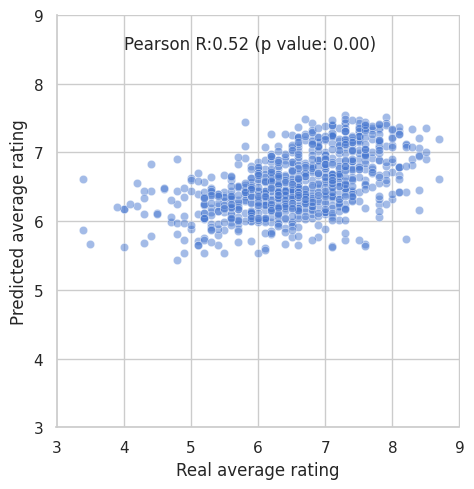

In [110]:
sns.relplot(x=train_y, y=y_pred, alpha=.5)
plt.xlim((3, 9))
plt.ylim((3, 9))
plt.xlabel("Real average rating")
plt.ylabel("Predicted average rating")
plt.text(4, 8.5,
         f"Pearson R:{corr.correlation:.2f} (p value: {corr.pvalue:.2f})")

We obtained better performances on all tasks using catch22 features instead of computing distances among raw time series.
We test only the best model for each task.

## Tear Down

In [111]:
try:
    rmtree(cachedir)
except FileNotFoundError:
    pass